# Phase 02 — Model Improvements: Tuning, Balancing, Ensembles, SVM & Error Analysis

This notebook continues from Phase 01 (notebooks 01–03) and extends the baseline with:

1. **SVM (Linear & RBF)** — Add Support Vector Machines to the comparison (LR, RF, XGB, SVM)
2. **Hyperparameter tuning** — RandomizedSearchCV on `7_+runtime` and `8_+vote_revenue` for both targets
3. **Balancing comparison** — SMOTE vs class_weight vs ADASYN for the imbalanced award-winner task
4. **Ensembles** — Soft/Hard Voting and Stacking on the best feature sets
5. **Feature importance & error analysis** — RF/XGB importance plots and FP/FN inspection for commercial success

Also trains on the optional **9_+release** feature set (release_month, release_year). Run from `phase_02/`; data and `src/` at project root.

## Setup

Paths are relative to project root (parent of `phase_02/`).

In [1]:
import sys
sys.path.append('..')

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import pickle
from pathlib import Path
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC

from src.data_loader import (load_main_dataset, load_nlp_features,
                             merge_datasets, get_unique_genres, create_genre_dummies)
from src.models import (prepare_modeling_data, create_splits, get_baseline_models,
                        train_baseline, train_with_tuning, build_ensembles, results_table,
                        f1_at_optimal_threshold, plot_confusion_matrices, plot_roc_curves,
                        plot_feature_importance)

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 12})

DATA_DIR = Path('../data')
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

---
## 1. Data Loading & Feature Engineering

Same pipeline as Phase 01: load merged data, build modeling subset, add TF-IDF SVD and **eight** progressive feature sets plus optional **9_+release**.

In [2]:
main_df = load_main_dataset(PROCESSED_DIR)
nlp_df = load_nlp_features(PROCESSED_DIR)
merged_df = merge_datasets(main_df, nlp_df)

unique_genres = get_unique_genres(merged_df)
merged_df = create_genre_dummies(merged_df, unique_genres)

Loaded main dataset: 12,950 movies
Loaded NLP features: 7,611 movies with subtitles
Merged dataset: 12,950 movies
Movies with NLP features: 7,611
Found 19 unique genres: Action, Adventure, Animation, Comedy, Crime, Documentary, Drama, Family, Fantasy, History, Horror, Music, Mystery, Romance, Science Fiction, TV Movie, Thriller, War, Western
Created 19 genre dummy columns


In [3]:
USE_BUDGET_IMPUTATION = False
if USE_BUDGET_IMPUTATION:
    median_budget = merged_df.loc[merged_df['budget'] > 0, 'budget'].median()
    merged_df = merged_df.copy()
    merged_df['budget'] = merged_df['budget'].replace(0, np.nan).fillna(median_budget)

modeling_criteria = (
    merged_df['word_count'].notna()
    & (merged_df['budget'] > 0)
    & (merged_df['revenue'] > 0)
    & (merged_df['runtime'] > 0)
)
modeling_df = merged_df[modeling_criteria].copy()

modeling_df['title_length'] = modeling_df['title'].fillna('').str.len()
modeling_df['budget_log'] = np.log10(modeling_df['budget'])
modeling_df['revenue_log'] = np.log10(modeling_df['revenue'])
modeling_df['vote_count_log'] = np.log10(modeling_df['vote_count'] + 1)

release_series = pd.to_datetime(modeling_df['release_date'], errors='coerce')
modeling_df['release_month'] = release_series.dt.month
modeling_df['release_year'] = release_series.dt.year
modeling_df['release_month'] = modeling_df['release_month'].fillna(6).astype(int)
modeling_df['release_year'] = modeling_df['release_year'].fillna(2000).astype(int)

print(f'Modeling subset: {len(modeling_df):,} movies')
print(f'  is_commercial pos rate: {modeling_df["is_commercial"].mean():.3f}')
print(f'  is_award_winner pos rate: {modeling_df["is_award_winner"].mean():.3f}')

Modeling subset: 5,791 movies
  is_commercial pos rate: 0.487
  is_award_winner pos rate: 0.157


In [4]:
N_SVD = 100
tfidf_path = PROCESSED_DIR / 'tfidf_matrix.npz'
corpus_ids_path = PROCESSED_DIR / 'tfidf_corpus_ids.pkl'

if tfidf_path.exists() and corpus_ids_path.exists():
    tfidf_matrix = scipy.sparse.load_npz(tfidf_path)
    with open(corpus_ids_path, 'rb') as f:
        corpus_ids = pickle.load(f)

    # Align TF-IDF rows with modeling_df to enable train-only SVD fit
    id_to_row = {mid: i for i, mid in enumerate(corpus_ids)}
    keep_idx = [id_to_row[mid] for mid in modeling_df['id'] if mid in id_to_row]
    tfidf_sub = tfidf_matrix[keep_idx]
    corpus_ids_sub = [corpus_ids[i] for i in keep_idx]

    svd = TruncatedSVD(n_components=N_SVD, random_state=RANDOM_SEED)
    X_svd = svd.fit_transform(tfidf_sub)
    tfidf_svd_cols = [f'tfidf_svd_{i+1}' for i in range(N_SVD)]
    tfidf_svd_df = pd.DataFrame(X_svd, columns=tfidf_svd_cols)
    tfidf_svd_df['id'] = corpus_ids_sub
    modeling_df = modeling_df.merge(tfidf_svd_df, on='id', how='left')
    modeling_df[tfidf_svd_cols] = modeling_df[tfidf_svd_cols].fillna(0)
    explained = svd.explained_variance_ratio_.sum()
    print(f'Added {N_SVD} TF-IDF SVD components (explained variance: {explained:.1%})')
    print(f'SVD fit on modeling-eligible subset only ({len(keep_idx):,} docs)')
else:
    tfidf_svd_cols = []
    print('TF-IDF matrix not found.')

Added 100 TF-IDF SVD components (explained variance: 31.7%)
SVD fit on modeling-eligible subset only (5,790 docs)


In [5]:
text_basic = [
    'word_count', 'sentence_count', 'avg_sentence_length', 'char_count',
    'type_token_ratio', 'hapax_legomena_ratio', 'unique_words',
]
text_vader = ['sentiment_compound', 'sentiment_pos', 'sentiment_neg', 'sentiment_neu']
nlp_optional = [
    'avg_word_length', 'sentence_length_std', 'textblob_polarity', 'textblob_subjectivity',
    'sentiment_compound_std', 'exclamation_ratio', 'question_ratio', 'emotional_intensity',
]
nlp_optional = [c for c in nlp_optional if c in modeling_df.columns]
text_full = text_basic + text_vader + nlp_optional + tfidf_svd_cols
genre_features = [f'genre_{g.lower()}' for g in unique_genres]

FEATURE_SET_CONFIG = {
    '7_+runtime': (
        text_full + genre_features + ['title_length', 'budget_log', 'runtime'],
        text_full + genre_features + ['title_length', 'budget_log', 'runtime'],
    ),
    '8_+vote_revenue': (
        text_full + genre_features + ['title_length', 'budget_log', 'runtime'],
        text_full + genre_features + ['title_length', 'budget_log', 'runtime', 'vote_count_log', 'revenue_log'],
    ),
}
release_features = [c for c in ['release_month', 'release_year'] if c in modeling_df.columns]
if release_features:
    base_7 = text_full + genre_features + ['title_length', 'budget_log', 'runtime']
    FEATURE_SET_CONFIG['9_+release'] = (base_7 + release_features, base_7 + release_features)

print('Feature sets for KT2:', list(FEATURE_SET_CONFIG.keys()))

Feature sets for KT2: ['7_+runtime', '8_+vote_revenue', '9_+release']


Train baselines (LR, RF, XGBoost with SMOTE) on **7_+runtime**, **8_+vote_revenue**, and **9_+release** only, to populate `all_splits` and `all_results` for the sections below.

In [6]:
all_splits = {}
all_results = {}
config_items = list(FEATURE_SET_CONFIG.items())

for set_name, (f_comm, f_award) in config_items:
    print(f'\n{"="*60}\nFeature set: {set_name}\n{"="*60}')
    splits_set = {}
    for target, feats in [('is_commercial', f_comm), ('is_award_winner', f_award)]:
        print(f'--- {target} ---')
        X, y = prepare_modeling_data(modeling_df, target, feats)
        splits_set[target] = create_splits(X, y)
    all_splits[set_name] = splits_set
    print('  Training commercial models...')
    res_comm = train_baseline(splits_set['is_commercial'], use_smote=True)
    print('  Training award models...')
    res_award = train_baseline(splits_set['is_award_winner'], use_smote=True)
    all_results[set_name] = {'is_commercial': res_comm, 'is_award_winner': res_award}


Feature set: 7_+runtime
--- is_commercial ---
Split: train=4053, val=869, test=869, pos_rate=0.487
--- is_award_winner ---
Split: train=4053, val=869, test=869, pos_rate=0.157
  Training commercial models...
  [1/3] Logistic Regression       CV F1: 0.606 ± 0.017 | Test F1: 0.585 (opt: 0.653) | AUC: 0.629  (0.5s)
  [2/3] Random Forest             CV F1: 0.592 ± 0.010 | Test F1: 0.549 (opt: 0.655) | AUC: 0.609  (10.2s)
  [3/3] XGBoost                   CV F1: 0.618 ± 0.019 | Test F1: 0.565 (opt: 0.656) | AUC: 0.619  (13.9s)
  Training award models...
  [1/3] Logistic Regression       CV F1: 0.840 ± 0.015 | Test F1: 0.386 (opt: 0.399) | AUC: 0.746  (0.5s)
  [2/3] Random Forest             CV F1: 0.920 ± 0.004 | Test F1: 0.373 (opt: 0.464) | AUC: 0.782  (17.4s)
  [3/3] XGBoost                   CV F1: 0.908 ± 0.006 | Test F1: 0.417 (opt: 0.456) | AUC: 0.767  (21.4s)

Feature set: 8_+vote_revenue
--- is_commercial ---
Split: train=4053, val=869, test=869, pos_rate=0.487
--- is_award_winner

---
## 2a. SVM (Linear & RBF)

Add **SVM** to the pipeline so we compare four classifiers (LR, RF, XGB, SVM). We train **SVM linear** and **SVM RBF** on the same splits with SMOTE, then merge results into `all_results` for tables and plots.

--- SVM: 7_+runtime / is_commercial ---
  [1/2] SVM (linear)              CV F1: 0.605 ± 0.015 | Test F1: 0.590 (opt: 0.657) | AUC: 0.632  (147.5s)
  [2/2] SVM (RBF)                 CV F1: 0.617 ± 0.025 | Test F1: 0.567 (opt: 0.657) | AUC: 0.622  (183.7s)
--- SVM: 7_+runtime / is_award_winner ---
  [1/2] SVM (linear)              CV F1: 0.844 ± 0.015 | Test F1: 0.413 (opt: 0.406) | AUC: 0.748  (110.8s)
  [2/2] SVM (RBF)                 CV F1: 0.920 ± 0.006 | Test F1: 0.369 (opt: 0.392) | AUC: 0.751  (137.4s)
--- SVM: 8_+vote_revenue / is_commercial ---
  [1/2] SVM (linear)              CV F1: 0.605 ± 0.015 | Test F1: 0.590 (opt: 0.657) | AUC: 0.632  (73.3s)
  [2/2] SVM (RBF)                 CV F1: 0.617 ± 0.025 | Test F1: 0.567 (opt: 0.657) | AUC: 0.622  (91.6s)
--- SVM: 8_+vote_revenue / is_award_winner ---
  [1/2] SVM (linear)              CV F1: 0.873 ± 0.014 | Test F1: 0.472 (opt: 0.486) | AUC: 0.814  (86.1s)
  [2/2] SVM (RBF)                 CV F1: 0.936 ± 0.004 | Test F1: 0.452 (

,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,Logistic Regression,0.585,0.629,0.593,0.185,0.580,0.591,0.653,0.606 ± 0.017
1,Random Forest,0.549,0.609,0.572,0.145,0.565,0.534,0.655,0.592 ± 0.010
2,XGBoost,0.565,0.619,0.579,0.159,0.570,0.560,0.656,0.618 ± 0.019
3,SVM (linear),0.590,0.632,0.596,0.192,0.583,0.598,0.657,0.605 ± 0.015
4,SVM (RBF),0.567,0.622,0.581,0.161,0.571,0.563,0.657,0.617 ± 0.025



7_+runtime — Award: LR, RF, XGB, SVM


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,Logistic Regression,0.386,0.746,0.645,0.253,0.327,0.471,0.399,0.840 ± 0.015
1,Random Forest,0.373,0.782,0.625,0.278,0.429,0.331,0.464,0.920 ± 0.004
2,XGBoost,0.417,0.767,0.657,0.304,0.401,0.434,0.456,0.908 ± 0.006
3,SVM (linear),0.413,0.748,0.667,0.286,0.345,0.515,0.406,0.844 ± 0.015
4,SVM (RBF),0.369,0.751,0.624,0.261,0.395,0.346,0.392,0.920 ± 0.006



8_+vote_revenue — Commercial: LR, RF, XGB, SVM


...

,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,Logistic Regression,0.607,0.642,0.618,0.235,0.608,0.605,0.655,0.618 ± 0.019
1,Random Forest,0.580,0.628,0.605,0.211,0.604,0.558,0.655,0.624 ± 0.019
2,XGBoost,0.588,0.631,0.602,0.205,0.594,0.582,0.653,0.633 ± 0.008
3,SVM (linear),0.608,0.645,0.617,0.233,0.606,0.610,0.662,0.616 ± 0.020
4,SVM (RBF),0.582,0.635,0.595,0.189,0.585,0.579,0.660,0.630 ± 0.028



9_+release — Award: LR, RF, XGB, SVM


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,Logistic Regression,0.415,0.757,0.664,0.291,0.358,0.493,0.410,0.851 ± 0.010
1,Random Forest,0.397,0.779,0.637,0.304,0.453,0.353,0.442,0.925 ± 0.002
2,XGBoost,0.420,0.766,0.658,0.308,0.407,0.434,0.427,0.913 ± 0.006
3,SVM (linear),0.409,0.760,0.661,0.282,0.349,0.493,0.418,0.850 ± 0.009
4,SVM (RBF),0.402,0.764,0.641,0.304,0.442,0.368,0.416,0.925 ± 0.004



7_+runtime — is_commercial (SVM)


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,SVM (linear),0.590,0.632,0.596,0.192,0.583,0.598,0.657,0.605 ± 0.015
1,SVM (RBF),0.567,0.622,0.581,0.161,0.571,0.563,0.657,0.617 ± 0.025


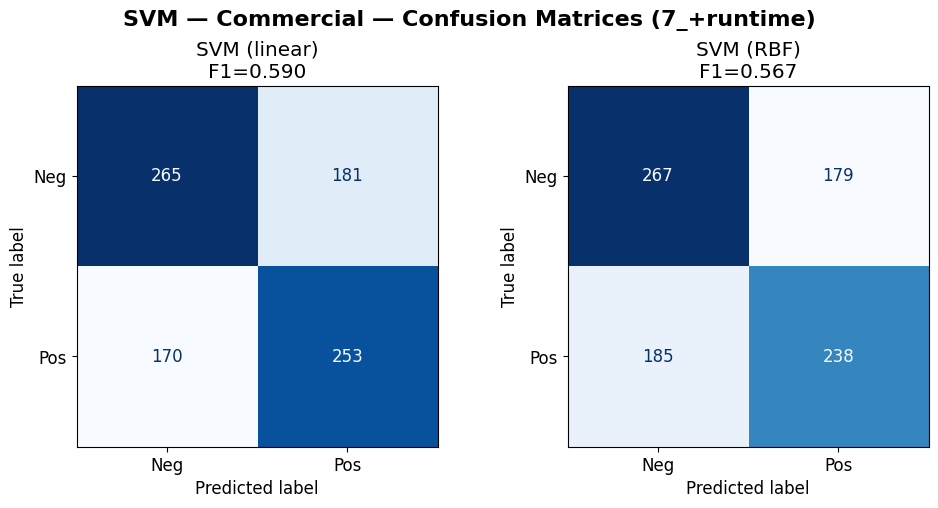

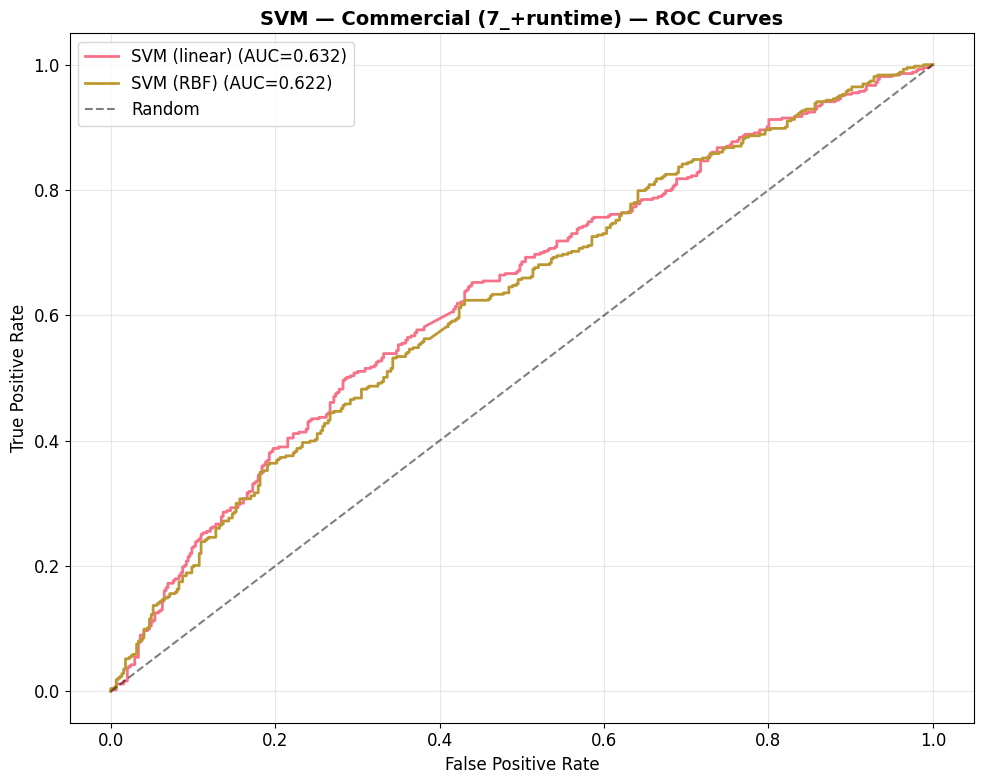


7_+runtime — is_award_winner (SVM)


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,SVM (linear),0.413,0.748,0.667,0.286,0.345,0.515,0.406,0.844 ± 0.015
1,SVM (RBF),0.369,0.751,0.624,0.261,0.395,0.346,0.392,0.920 ± 0.006


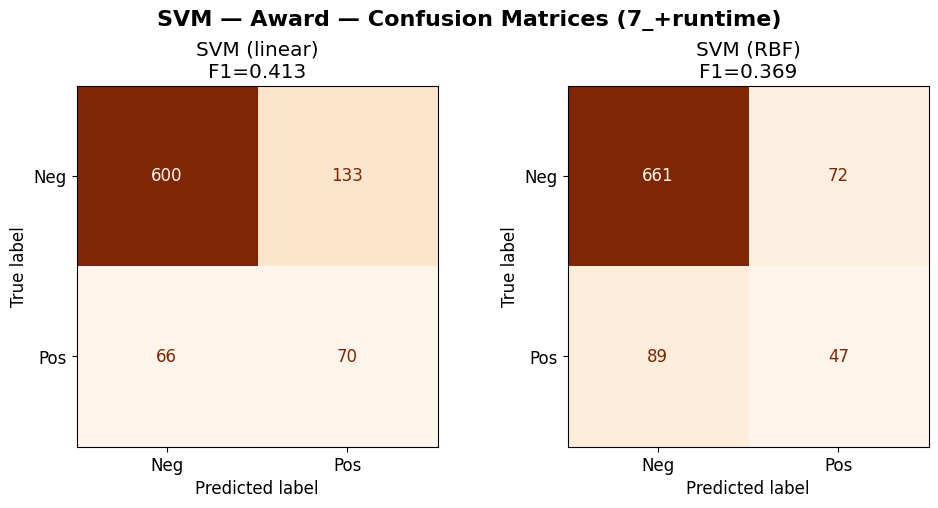

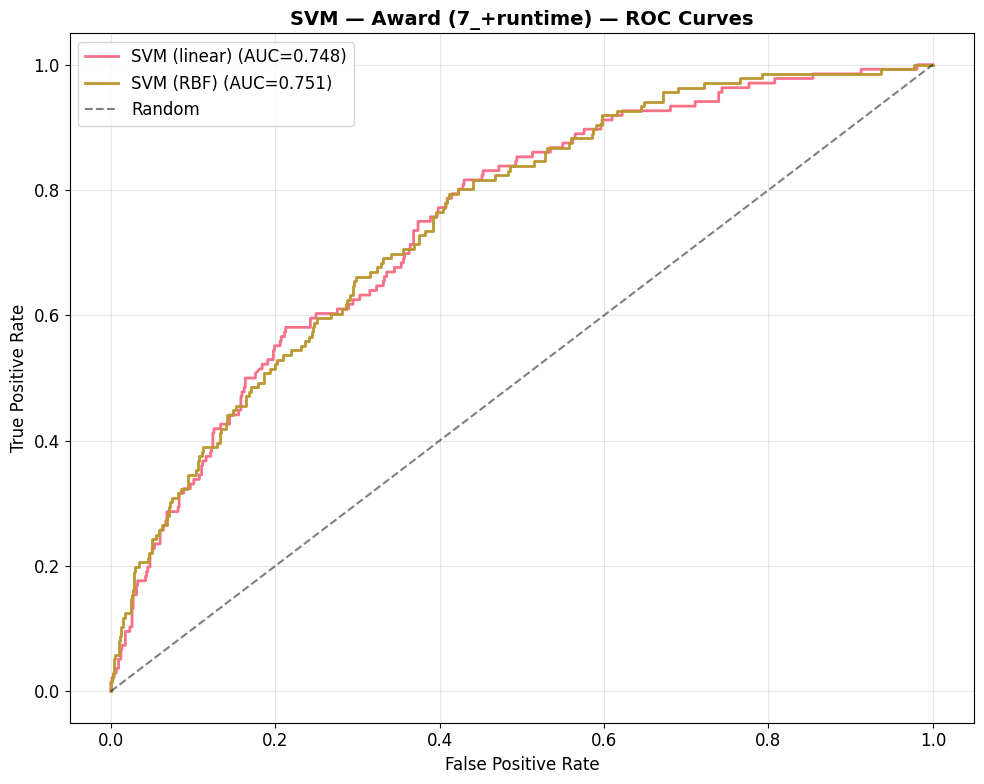


8_+vote_revenue — is_commercial (SVM)


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,SVM (linear),0.590,0.632,0.596,0.192,0.583,0.598,0.657,0.605 ± 0.015
1,SVM (RBF),0.567,0.622,0.581,0.161,0.571,0.563,0.657,0.617 ± 0.025


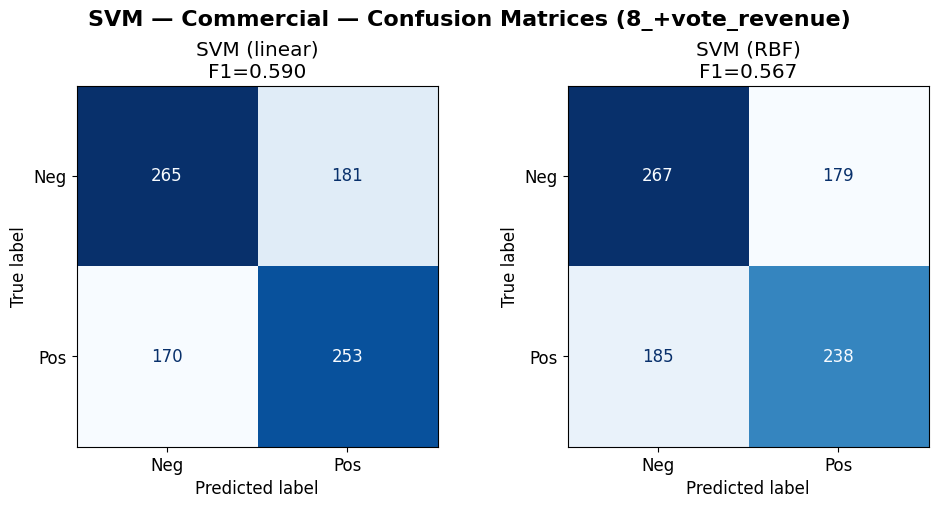

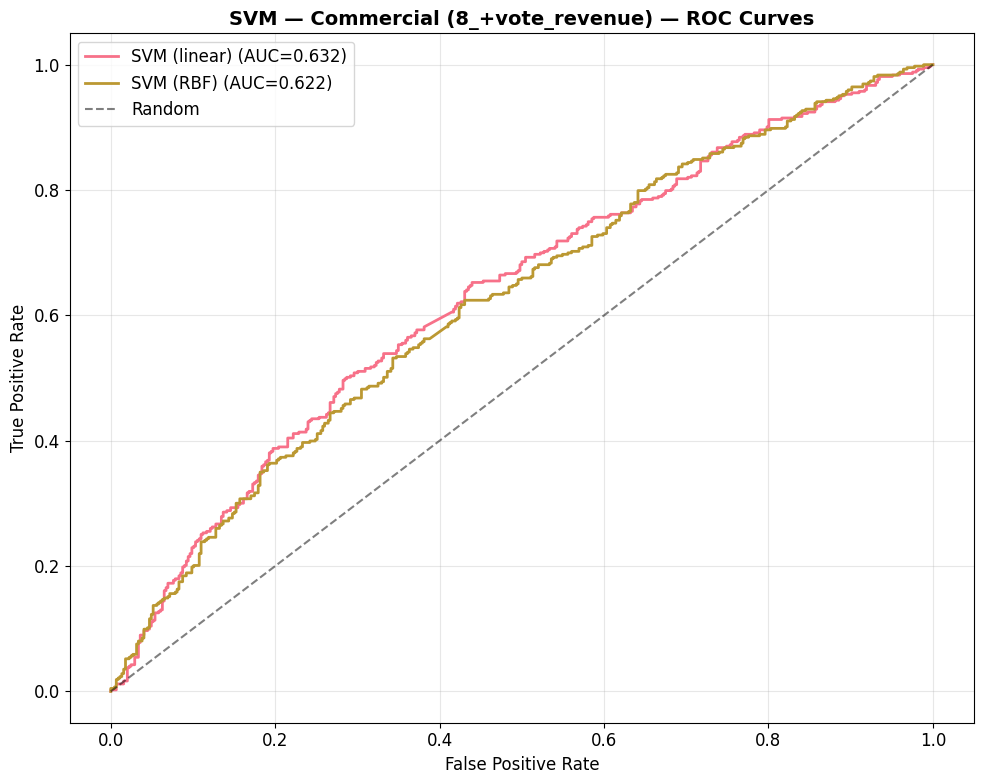


8_+vote_revenue — is_award_winner (SVM)


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,SVM (linear),0.472,0.814,0.703,0.362,0.412,0.551,0.486,0.873 ± 0.014
1,SVM (RBF),0.452,0.810,0.669,0.362,0.491,0.419,0.421,0.936 ± 0.004


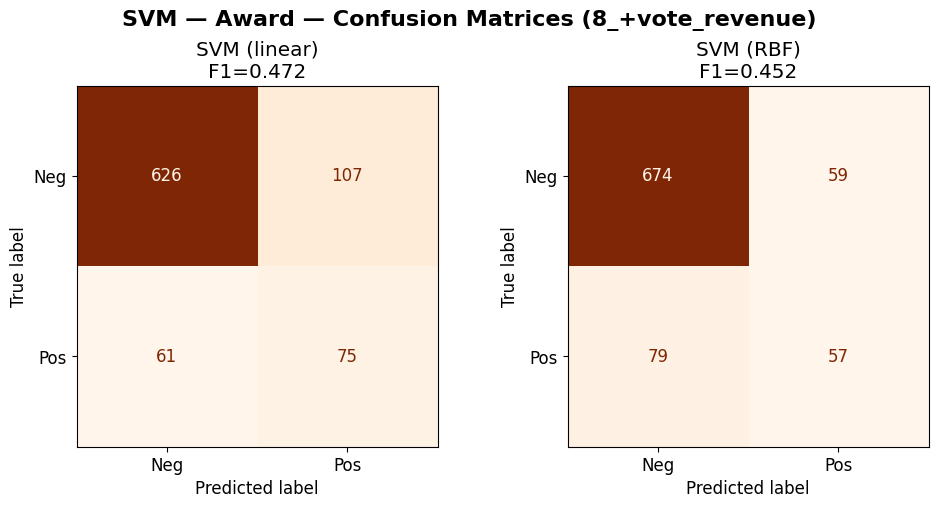

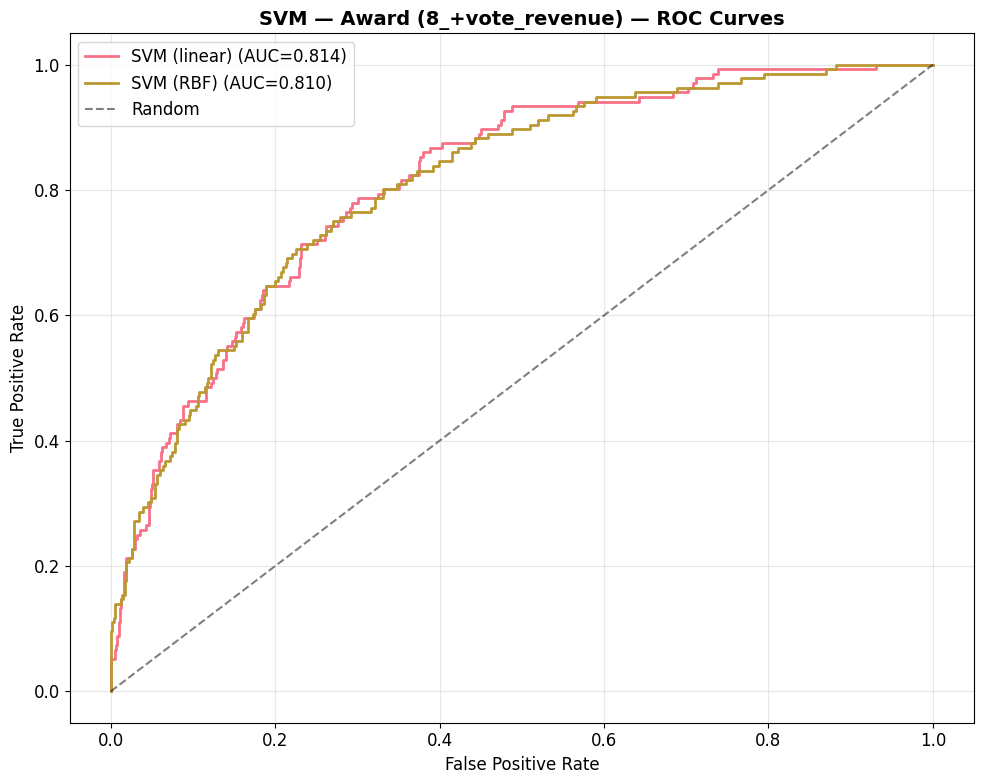


9_+release — is_commercial (SVM)


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,SVM (linear),0.608,0.645,0.617,0.233,0.606,0.610,0.662,0.616 ± 0.020
1,SVM (RBF),0.582,0.635,0.595,0.189,0.585,0.579,0.660,0.630 ± 0.028


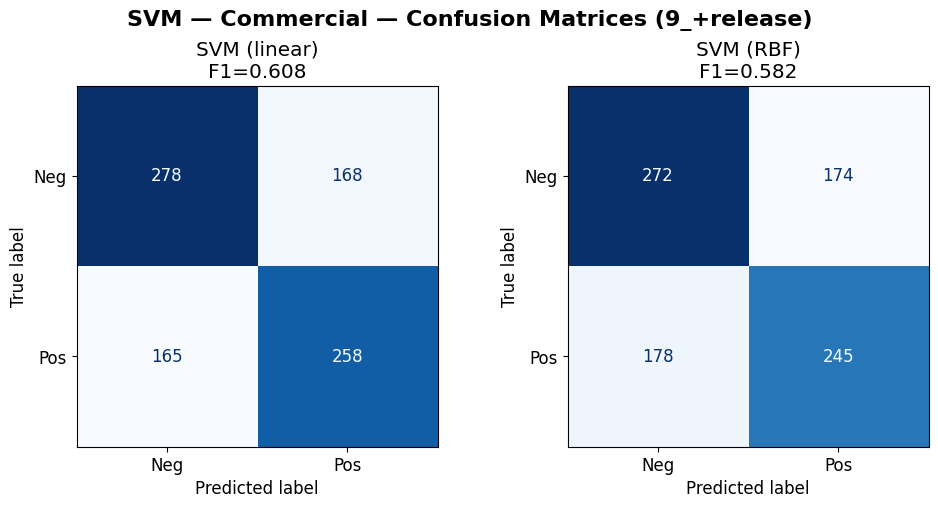

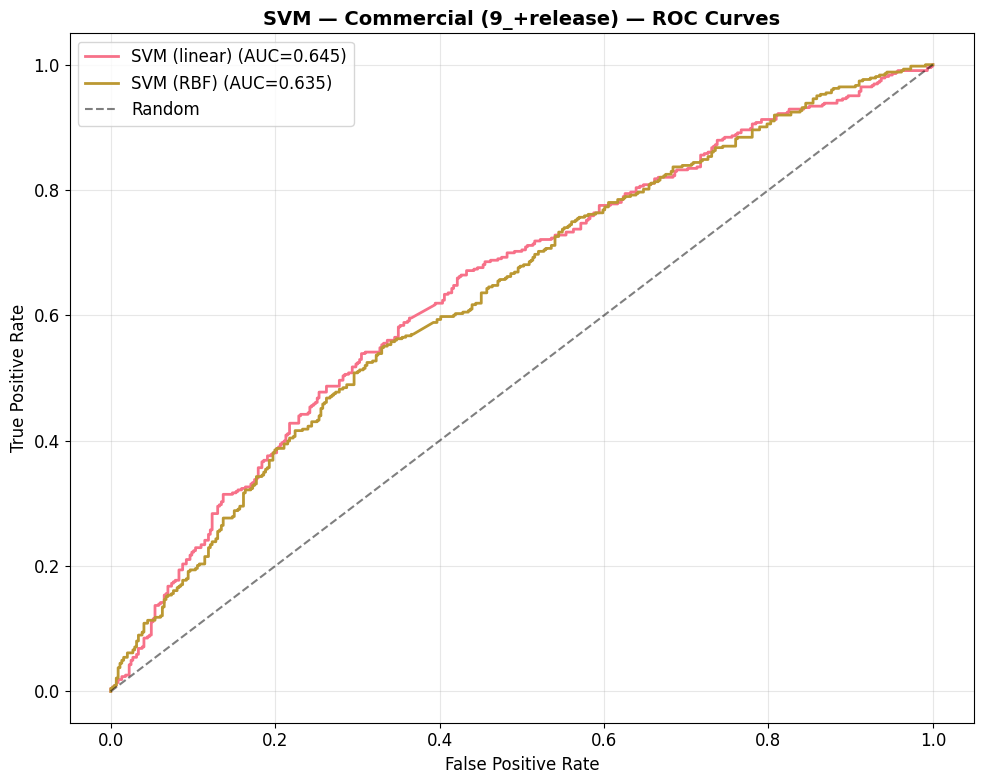


9_+release — is_award_winner (SVM)


,Model,Test F1,Test AUC,Bal. Acc.,MCC,Precision,Recall,F1 (opt),CV F1
0,SVM (linear),0.409,0.760,0.661,0.282,0.349,0.493,0.418,0.850 ± 0.009
1,SVM (RBF),0.402,0.764,0.641,0.304,0.442,0.368,0.416,0.925 ± 0.004


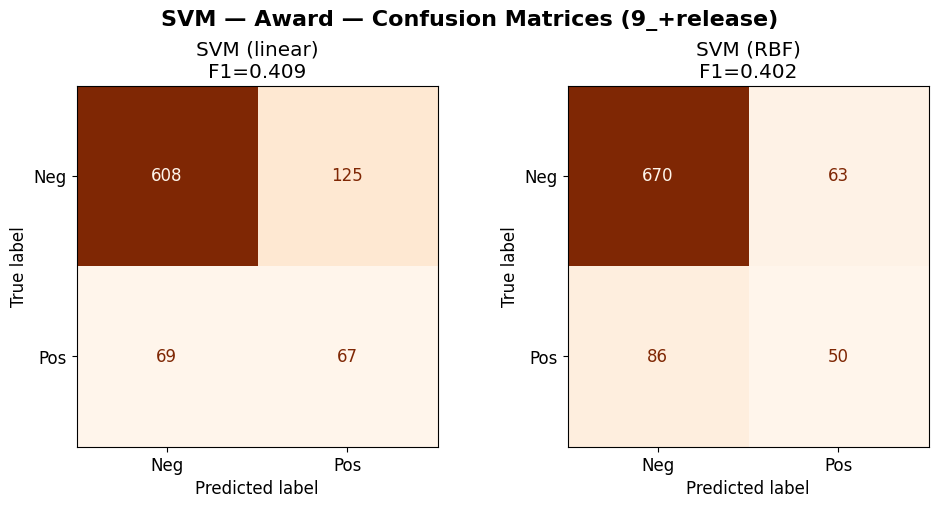

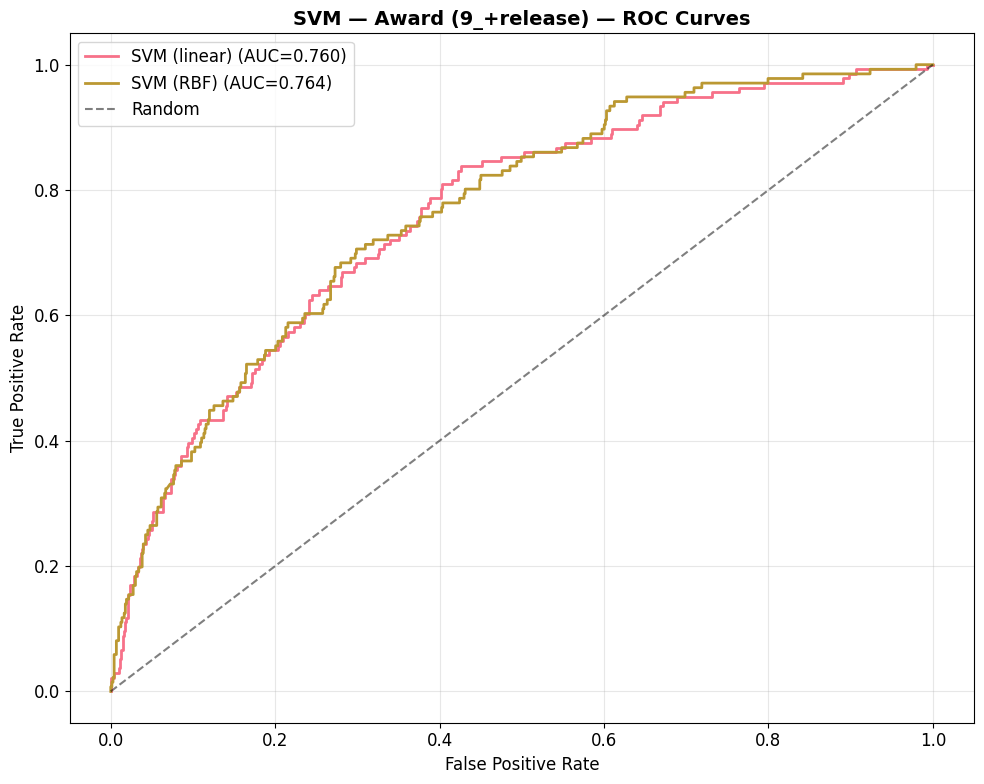

In [7]:
svm_models = {
    'SVM (linear)': SVC(kernel='linear', class_weight='balanced', probability=True, random_state=RANDOM_SEED),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_SEED),
}
KT2_SVM_SETS = [s for s in ['7_+runtime', '8_+vote_revenue', '9_+release'] if s in all_splits]
for set_name in KT2_SVM_SETS:
    for target in ['is_commercial', 'is_award_winner']:
        print(f'--- SVM: {set_name} / {target} ---')
        res = train_baseline(all_splits[set_name][target], models=svm_models, use_smote=True)
        all_results[set_name][target].update(res)

# Combined baseline + SVM table (all five model families)
baseline_labels = ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM (linear)', 'SVM (RBF)']
for set_name in KT2_SVM_SETS:
    for target, label in [('is_commercial', 'Commercial'), ('is_award_winner', 'Award')]:
        five = {k: v for k, v in all_results[set_name][target].items() if k in baseline_labels}
        if five:
            print(f'\n{set_name} — {label}: LR, RF, XGB, SVM')
            display(results_table(five))

# SVM-only confusion / ROC
for set_name in KT2_SVM_SETS:
    for target, label in [('is_commercial', 'Commercial'), ('is_award_winner', 'Award')]:
        svm_only = {k: v for k, v in all_results[set_name][target].items() if k.startswith('SVM')}
        if svm_only:
            print(f'\n{set_name} — {target} (SVM)')
            display(results_table(svm_only))
            plot_confusion_matrices(svm_only, f'SVM — {label}', set_name,
                                    save_path=FIGURES_DIR / f'svm_confusion_{set_name}_{target}.png')
            plot_roc_curves(svm_only, f'SVM — {label} ({set_name})',
                            save_path=FIGURES_DIR / f'svm_roc_{set_name}_{target}.png')

---
## 2b. Hyperparameter Tuning (7_+runtime and 8_+vote_revenue)

We run **RandomizedSearchCV** on the best feature sets for both targets to see if tuning improves over the baseline. Results include F1, F1@opt, AUC, and balanced accuracy.

In [8]:
TUNING_SETS = ['7_+runtime', '8_+vote_revenue']
tuning_results = {}
n_iter = 25  # RandomizedSearchCV iterations per model

for set_name in TUNING_SETS:
    if set_name not in all_splits:
        continue
    tuning_results[set_name] = {}
    for target in ['is_commercial', 'is_award_winner']:
        print(f'\n--- Tuning {set_name} / {target} (class_weight) ---')
        tuning_results[set_name][target] = train_with_tuning(
            all_splits[set_name][target], balancing='class_weight', n_iter=n_iter)

# Summary: best tuned vs baseline
for set_name in TUNING_SETS:
    if set_name not in tuning_results:
        continue
    for target in ['is_commercial', 'is_award_winner']:
        r = tuning_results[set_name][target]
        baseline = all_results.get(set_name, {}).get(target, {})
        print(f'\n{set_name} — {target}:')
        for name in ['LogReg', 'RF', 'XGB', 'SVM_linear', 'SVM_rbf']:
            if name in r:
                bname = {'LogReg': 'Logistic Regression', 'RF': 'Random Forest', 'XGB': 'XGBoost',
                         'SVM_linear': 'SVM (linear)', 'SVM_rbf': 'SVM (RBF)'}.get(name, name)
                b = baseline.get(bname, {})
                opt_val = r[name].get('test_f1_opt') or 0
                b_f1, b_auc = b.get('test_f1') or 0, b.get('test_auc') or 0
                print(f'  {name}: Test F1={r[name]["test_f1"]:.3f} (opt={opt_val:.3f}) AUC={r[name]["test_auc"]:.3f}  |  baseline F1={b_f1:.3f} AUC={b_auc:.3f}')


--- Tuning 7_+runtime / is_commercial (class_weight) ---
  [1/5] Training LogReg...
    CV F1: 0.615 ± 0.012 | Test F1: 0.594 | AUC: 0.626  (11.9s)
  [2/5] Training RF...
    CV F1: 0.585 ± 0.018 | Test F1: 0.567 | AUC: 0.631  (87.9s)
  [3/5] Training XGB...
    CV F1: 0.604 ± 0.018 | Test F1: 0.580 | AUC: 0.630  (167.1s)
  [4/5] Training SVM_linear...
    CV F1: 0.615 ± 0.011 | Test F1: 0.594 | AUC: 0.628  (1050.6s)
  [5/5] Training SVM_rbf...
    CV F1: 0.601 ± 0.014 | Test F1: 0.569 | AUC: 0.627  (1165.9s)

--- Tuning 7_+runtime / is_award_winner (class_weight) ---
  [1/5] Training LogReg...
    CV F1: 0.476 ± 0.012 | Test F1: 0.473 | AUC: 0.802  (15.5s)
  [2/5] Training RF...
    CV F1: 0.392 ± 0.040 | Test F1: 0.314 | AUC: 0.794  (91.3s)
  [3/5] Training XGB...
    CV F1: 0.487 ± 0.018 | Test F1: 0.473 | AUC: 0.801  (169.0s)
  [4/5] Training SVM_linear...
    CV F1: 0.466 ± 0.017 | Test F1: 0.470 | AUC: 0.798  (969.7s)
  [5/5] Training SVM_rbf...
    CV F1: 0.469 ± 0.014 | Test F

### Baseline vs tuned (heatmap)

Per-model **Test F1** and **F1@opt** for `7_+runtime` and `8_+vote_revenue`: baseline (`all_results` after SVM) vs **RandomizedSearchCV** (`tuning_results`).

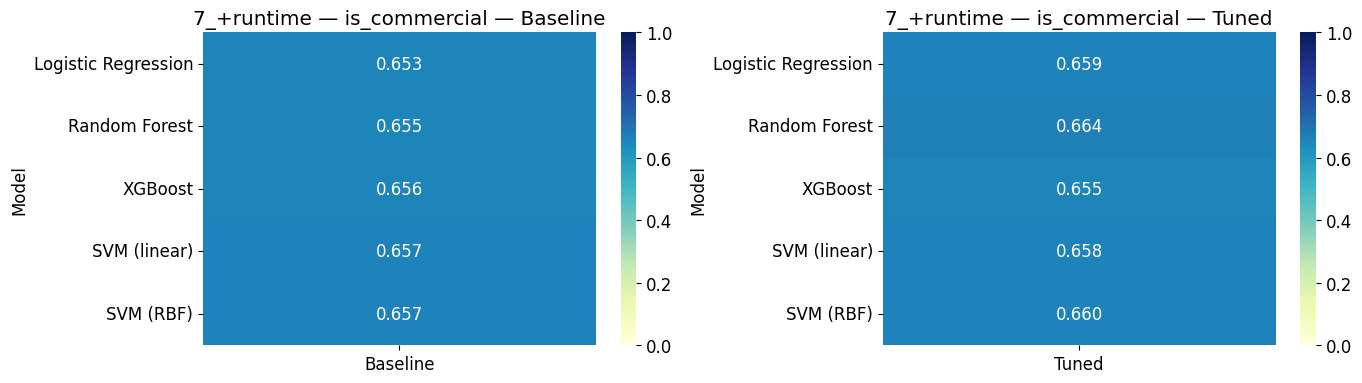

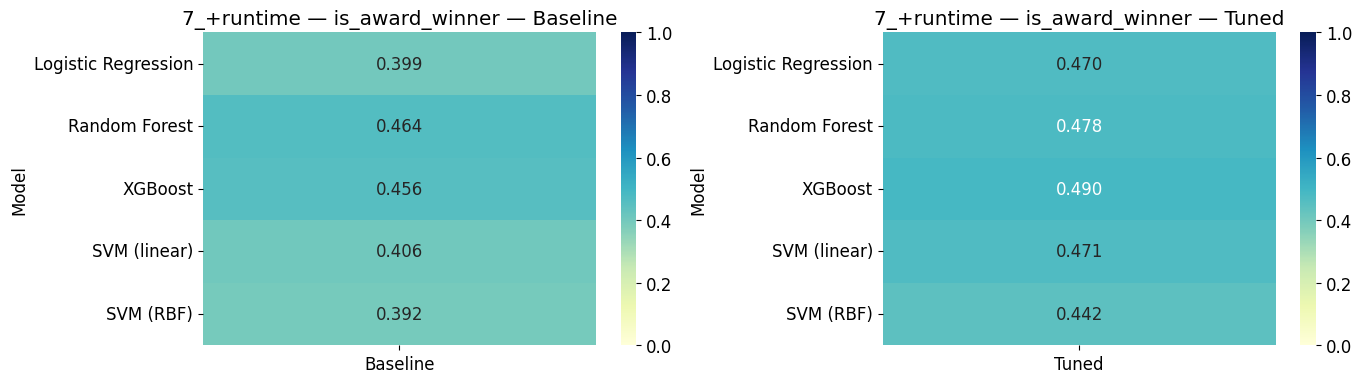

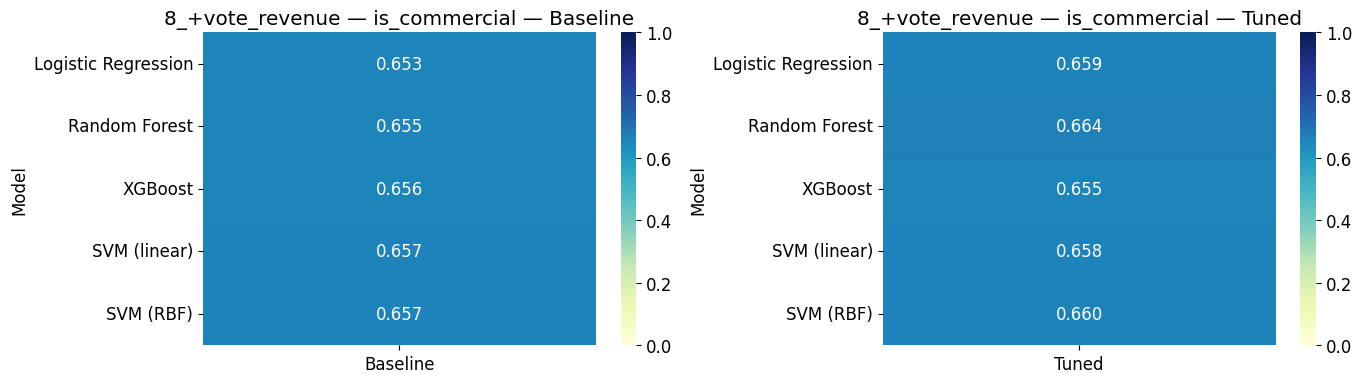

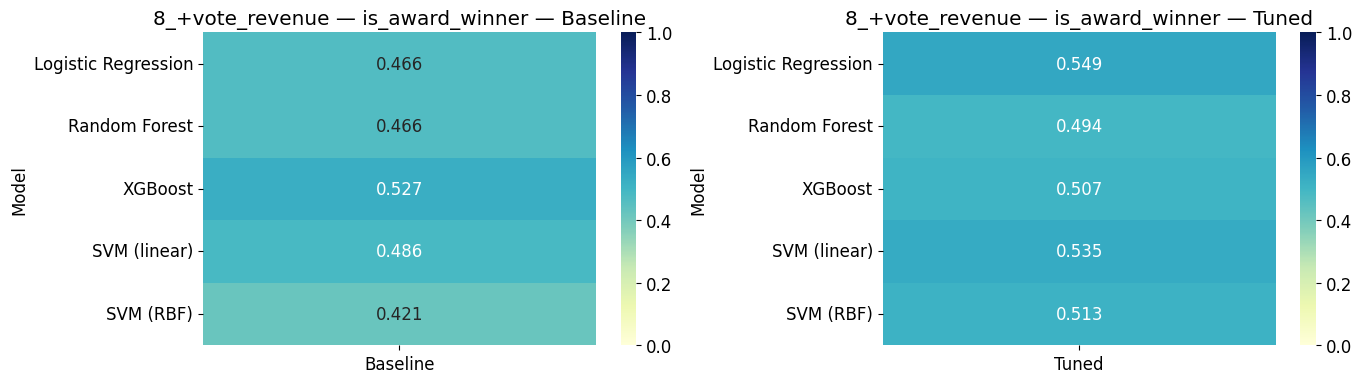

In [9]:
name_map = {'LogReg': 'Logistic Regression', 'RF': 'Random Forest', 'XGB': 'XGBoost',
            'SVM_linear': 'SVM (linear)', 'SVM_rbf': 'SVM (RBF)'}

def baseline_vs_tuned_heatmap(set_name, target_key, metric_key='test_f1_opt'):
    """metric_key: 'test_f1', 'test_f1_opt', 'test_auc', etc."""
    base = all_results.get(set_name, {}).get(target_key, {})
    tuned = tuning_results.get(set_name, {}).get(target_key, {})
    fallback = 'test_f1'
    rows = []
    for short, long in name_map.items():
        if short not in tuned:
            continue
        b = base.get(long, {})
        rows.append({
            'Model': long,
            'Baseline': b.get(metric_key) or b.get(fallback) or np.nan,
            'Tuned': tuned[short].get(metric_key) or tuned[short].get(fallback),
        })
    if not rows:
        print(f'No data for {set_name} / {target_key}')
        return
    comp = pd.DataFrame(rows).set_index('Model')
    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(comp) * 0.45)))
    for ax, col in zip(axes, ['Baseline', 'Tuned']):
        sns.heatmap(comp[[col]], annot=True, fmt='.3f', cmap='YlGnBu', ax=ax, vmin=0, vmax=1)
        ax.set_title(f'{set_name} — {target_key} — {col}')
    plt.tight_layout()
    fn = f'kt2_baseline_vs_tuned_{set_name}_{target_key}.png'.replace(' ', '_')
    plt.savefig(FIGURES_DIR / fn, dpi=150, bbox_inches='tight')
    plt.show()

for sn in TUNING_SETS:
    if sn not in tuning_results:
        continue
    for tk in ['is_commercial', 'is_award_winner']:
        baseline_vs_tuned_heatmap(sn, tk)

## 2c. Balancing: SMOTE vs Class-Weight vs ADASYN (Award)

For the award task (imbalanced), we compare three balancing strategies on 7_+runtime and 8_+vote_revenue: **class_weight**, **SMOTE**, and **ADASYN**. Validation F1 and test AUC help choose the best.

In [10]:
balancing_comparison = {}
for set_name in ['7_+runtime', '8_+vote_revenue']:
    if set_name not in all_splits:
        continue
    split = all_splits[set_name]['is_award_winner']
    balancing_comparison[set_name] = {}
    for bal in ['class_weight', 'smote', 'adasyn']:
        print(f'\n--- {set_name} / is_award_winner — balancing={bal} ---')
        balancing_comparison[set_name][bal] = train_with_tuning(split, balancing=bal, n_iter=15)

print('\nBalancing comparison (Award) — Test F1 (opt) / AUC:')
for set_name in balancing_comparison:
    print(f'  {set_name}:')
    for bal in ['class_weight', 'smote', 'adasyn']:
        r = balancing_comparison[set_name][bal]
        best_f1 = max(r[n].get('test_f1_opt') or r[n]['test_f1'] for n in r)
        best_auc = max(r[n]['test_auc'] for n in r)
        print(f'    {bal}: best F1@opt ~{best_f1:.3f}, best AUC ~{best_auc:.3f}')


--- 7_+runtime / is_award_winner — balancing=class_weight ---
  [1/5] Training LogReg...
    CV F1: 0.476 ± 0.012 | Test F1: 0.473 | AUC: 0.802  (11.7s)
  [2/5] Training RF...
    CV F1: 0.366 ± 0.030 | Test F1: 0.340 | AUC: 0.789  (62.8s)
  [3/5] Training XGB...
    CV F1: 0.498 ± 0.016 | Test F1: 0.509 | AUC: 0.805  (130.4s)
  [4/5] Training SVM_linear...
    CV F1: 0.466 ± 0.017 | Test F1: 0.470 | AUC: 0.798  (905.8s)
  [5/5] Training SVM_rbf...
    CV F1: 0.469 ± 0.014 | Test F1: 0.455 | AUC: 0.785  (983.1s)

--- 7_+runtime / is_award_winner — balancing=smote ---
  [1/5] Training LogReg...
    CV F1: 0.841 ± 0.011 | Test F1: 0.399 | AUC: 0.753  (5.6s)
  [2/5] Training RF...
    CV F1: 0.921 ± 0.006 | Test F1: 0.364 | AUC: 0.789  (126.2s)
  [3/5] Training XGB...
    CV F1: 0.921 ± 0.007 | Test F1: 0.351 | AUC: 0.777  (188.1s)
  [4/5] Training SVM_linear...
    CV F1: 0.846 ± 0.010 | Test F1: 0.413 | AUC: 0.753  (477.8s)
  [5/5] Training SVM_rbf...
    CV F1: 0.954 ± 0.004 | Test F1

## 2d. Ensembles on 7_+runtime and 8_+vote_revenue

We train **Soft Voting**, **Hard Voting**, and **Stacking (LR)** ensembles on the best feature sets for both targets and compare Test F1 / AUC to the best single model.

In [11]:
ensemble_results = {}
for set_name in ['7_+runtime', '8_+vote_revenue']:
    if set_name not in all_splits:
        continue
    ensemble_results[set_name] = {}
    for target in ['is_commercial', 'is_award_winner']:
        print(f'\n--- Ensembles: {set_name} / {target} ---')
        ensemble_results[set_name][target] = build_ensembles(all_splits[set_name][target], use_smote=True)

for set_name in ['7_+runtime', '8_+vote_revenue']:
    if set_name not in ensemble_results:
        continue
    print(f'\nEnsemble vs best baseline ({set_name}):')
    for target in ['is_commercial', 'is_award_winner']:
        base = all_results[set_name][target]
        best_single_f1 = max(r['test_f1'] for r in base.values())
        best_single_auc = max(r['test_auc'] for r in base.values())
        ens = ensemble_results[set_name][target]
        stack_f1 = ens['Stacking (LR)']['test_f1']
        stack_auc = ens['Stacking (LR)']['test_auc'] or 0
        print(f'  {target}: best single F1={best_single_f1:.3f} AUC={best_single_auc:.3f}  |  Stacking F1={stack_f1:.3f} AUC={stack_auc:.3f}')


--- Ensembles: 7_+runtime / is_commercial ---
  [1/3] Training Soft Voting...
    Test F1: 0.592 | AUC: 0.645  (9.9s)
  [2/3] Training Hard Voting...
    Test F1: 0.565 | AUC: N/A  (19.0s)
  [3/3] Training Stacking (LR)...
    Test F1: 0.578 | AUC: 0.645  (63.3s)

--- Ensembles: 7_+runtime / is_award_winner ---
  [1/3] Training Soft Voting...
    Test F1: 0.388 | AUC: 0.777  (14.0s)
  [2/3] Training Hard Voting...
    Test F1: 0.391 | AUC: N/A  (28.6s)
  [3/3] Training Stacking (LR)...
    Test F1: 0.349 | AUC: 0.766  (97.5s)

--- Ensembles: 8_+vote_revenue / is_commercial ---
  [1/3] Training Soft Voting...
    Test F1: 0.592 | AUC: 0.645  (11.6s)
  [2/3] Training Hard Voting...
    Test F1: 0.565 | AUC: N/A  (22.4s)
  [3/3] Training Stacking (LR)...
    Test F1: 0.578 | AUC: 0.645  (69.1s)

--- Ensembles: 8_+vote_revenue / is_award_winner ---
  [1/3] Training Soft Voting...
    Test F1: 0.502 | AUC: 0.830  (14.3s)
  [2/3] Training Hard Voting...
    Test F1: 0.475 | AUC: N/A  (28.3s

## 2e. Feature Importance and Error Analysis (Is Commercial)

We plot **feature importance** for Random Forest and XGBoost on 7_+runtime (commercial) and inspect **false positives** and **false negatives** to guide further feature engineering.

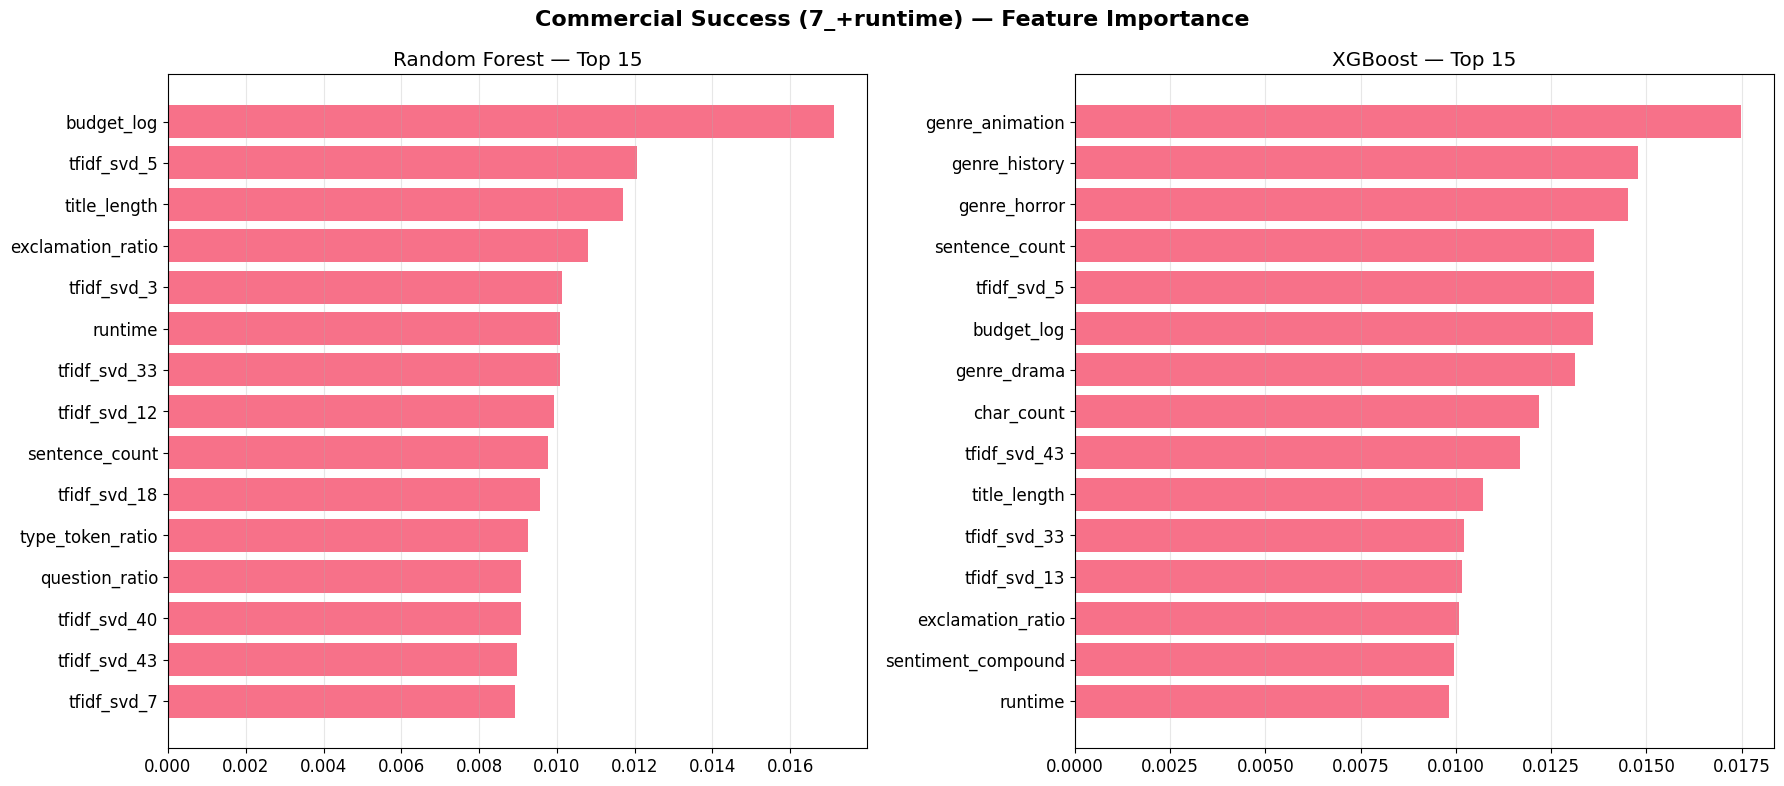

Commercial (7_+runtime, Logistic Regression): FP=181, FN=173, Total test=869

Sample FP (predicted commercial, actually not):
                        title      budget     revenue  runtime
3252              Freedomland  37665000.0  14655628.0    113.0
5175     Assassination Nation   7000000.0   2900000.0    108.0
5493        American Underdog  25000000.0  26514814.0    112.0
4814          A Monster Calls  43000000.0  47309313.0    108.0
2498  Josie and the Pussycats  22000000.0  14866444.0     98.0

Sample FN (predicted not commercial, actually commercial):
                      title      budget      revenue  runtime
3693             Zombieland  23600000.0  102391540.0     87.0
2898               Cellular  25000000.0   57678321.0     94.0
2718        The Italian Job  60000000.0  176070171.0    110.0
3191             Date Movie  20000000.0   85749034.0     83.0
5391  Promising Young Woman  10000000.0   20379604.0    113.0


In [13]:
comm_split = all_splits['7_+runtime']['is_commercial']
comm_res = all_results['7_+runtime']['is_commercial']
feat_cols = comm_split['features']
plot_feature_importance(comm_res, feat_cols, 'Commercial Success (7_+runtime)',
                        models=('Random Forest', 'XGBoost'),
                        save_path=FIGURES_DIR / 'kt2_commercial_feature_importance_7runtime.png')

y_test = comm_res['Logistic Regression']['y_test']
y_pred = comm_res['Logistic Regression']['y_test_pred']
fp = (y_pred == 1) & (y_test.values == 0)
fn = (y_pred == 0) & (y_test.values == 1)
print(f'Commercial (7_+runtime, Logistic Regression): FP={fp.sum()}, FN={fn.sum()}, Total test={len(y_test)}')

test_idx = comm_split['X_test'].index
err_df = modeling_df.loc[test_idx].copy()
err_df['true'] = y_test.values
err_df['pred'] = y_pred
err_df['fp'] = fp
err_df['fn'] = fn
print('\nSample FP (predicted commercial, actually not):')
print(err_df[err_df['fp']][['title', 'budget', 'revenue', 'runtime']].head(5).to_string())
print('\nSample FN (predicted not commercial, actually commercial):')
print(err_df[err_df['fn']][['title', 'budget', 'revenue', 'runtime']].head(5).to_string())

## 3. KT2 summary (fill from tables above)

| Task | KT2 target F1(opt) | KT2 target AUC | Best baseline (this run) | Best tuned (this run) |
|------|-------------------|----------------|--------------------------|------------------------|
| Commercial | ≥ 0.68 | ≥ 0.70 | _from `table_best` / prints_ | _from tuning_results_ |
| Award | ≥ 0.55 | ≥ 0.82 | | |

_Notebook **05** / **06** load `data/processed/phase2_results.pkl` produced below — run this notebook first._

In [14]:
import pickle

results_bundle = {
    'all_results': all_results,
    'tuning_results': tuning_results,
    'balancing_comparison': balancing_comparison,
    'ensemble_results': ensemble_results,
    'all_splits': all_splits,
    'modeling_df': modeling_df,
    'unique_genres': unique_genres,
    'RANDOM_SEED': RANDOM_SEED,
}
out_pkl = PROCESSED_DIR / 'phase2_results.pkl'
with open(out_pkl, 'wb') as f:
    pickle.dump(results_bundle, f)
print(f'Saved Phase 2 bundle to {out_pkl}')

Saved Phase 2 bundle to ..\data\processed\phase2_results.pkl
